In [1]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import pandas as pd
from scipy.special import logsumexp, xlogy
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm import tqdm

In [2]:
os.getcwd()

'/home/windows11/llm-26/mlp'

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    return sigmoid(x) * (1 - sigmoid(x))


In [4]:
def softmax(x):
    exp = np.exp(x)
    partition = np.sum(exp)
    return exp / partition

def cross_entropy(y_prob, y_true):
    entropy = y_true * np.log(y_prob)
    loss = np.sum(entropy)
    return loss

In [5]:
x = np.random.randn(5,1)
x.shape,softmax(x),softmax(x).shape,np.sum(softmax(x))


((5, 1),
 array([[0.34182995],
        [0.03751055],
        [0.45256321],
        [0.05519662],
        [0.11289967]]),
 (5, 1),
 np.float64(1.0))

In [6]:
class MLP_3:
    def __init__(self, input_size, hidden_size, output_size=10,weight_decay=0.0001):
        #初始化权重和偏置参数
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1,hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1,output_size))
        self.reg = weight_decay

    def forward(self, X, activate="relu"):
        #隐藏层输出
        self.z1 = X @ self.W1 + self.b1

        #激活函数输出
        if activate == "relu":
            self.acti_func = relu
            self.acti_grad = relu_grad
        else:
            self.acti_func = sigmoid
            self.acti_grad = sigmoid_grad

        self.a1 = self.acti_func(self.z1)

        #再次线性组合
        self.z2 = self.a1 @ self.W2 + self.b2

        #输出logit
        return self.z2
    
    def softmax_cross_entropy_loss(self, logits, y_true):
        n = y_true.shape[0]
        lse = logsumexp(logits, axis=1, keepdims=True)
        log_probs = logits - lse
        loss = -np.sum(y_true * log_probs) / n

        #正则化
        reg_loss = 0.5 * self.reg * (np.sum(self.W1**2) + np.sum(self.W2**2))

        #总loss
        total_loss = loss + reg_loss
        
        return total_loss
    
    def backward(self, X, y_prob, y_true):
        #输出层梯度
        n = X.shape[0]
        dz2 = (y_prob - y_true) / n #loss对z2（默认十个分量）的梯度

        #第二次线性组合参数的梯度
        self.dW2 = self.a1.T @ dz2
        self.db2 = np.sum(dz2, axis=0, keepdims=True)

        #激活函数梯度
        da1 = dz2 @ self.W2.T
        dz1 = self.acti_grad(self.z1) * da1

        #隐藏层输入参数的梯度
        self.dW1 = X.T @ dz1
        self.db1 = np.sum(dz1, axis=0, keepdims=True)

        #正则化梯度
        self.dW1 += self.reg * self.W1
        self.dW2 += self.reg * self.W2

    def update(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

    def predict(self, X_test):
        y_pred_logit = self.forward(X_test)
        y_prob = softmax(y_pred_logit)
        return np.argmax(y_prob, axis=1)

In [7]:
#处理图像
data_dir = "EuroSAT_RGB"
class_names = []
for name in os.listdir(data_dir):
    if os.path.isdir(os.path.join(data_dir, name)):
        class_names.append(name)
X = []
y = []

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        X.append(img)
        y.append(class_name)


In [8]:
X = np.array(X)
#将X归一化
X = X / 255
#将每张图片展平成一维
X = X.reshape(X.shape[0], -1)
#将y转化成onehot编码
y = pd.get_dummies(y)
y = y.astype(int)
y = y.to_numpy()

In [9]:
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42,stratify=y_test_val)

In [10]:
len(X_train),len(X_test_val),len(X_test)

(21600, 5400, 2700)

In [30]:
'''epochs = 20
lr = 0.1
decay_rate = 0.99
batch_size = 64
num_batches = (X_train.shape[0] + batch_size - 1) // batch_size'''
model = MLP_3(X.shape[1], 64, y.shape[1])

In [31]:
def trainer(model,X_train,y_train,X_val,y_val, epochs=80, batch_size=256, lr=0.1, decay_rate=0.95, lr_threshold=0.04):
    #训练模型，返回训练过程loss、val_loss、accuracy、
    start_time = time.time()
    loss_list = []
    val_loss_list = []
    accuracy_list = []
    num_batches = (X_train.shape[0] + batch_size - 1) // batch_size
    best_val_loss = float('inf')
    best_params = None
    
    for epoch in range(epochs):
        indices = np.random.permutation(X_train.shape[0])
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        with tqdm(total=num_batches, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            
            #每个epoch进行num_batches次训练
            for i in range(num_batches):
                start = i * batch_size
                end = min(start + batch_size, X_train.shape[0])
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                y_pred = model.forward(X_train)
                loss = model.softmax_cross_entropy_loss(y_pred,y_train)
                pbar.update(1)
                pbar.set_postfix({"loss": f"{loss:.4f}"})
                
                model.backward(X_train,y_pred,y_train)
                model.update(lr)
                if lr > lr_threshold:
                    lr *= decay_rate
                else:
                    lr = lr_threshold
            
            end_time = time.time()
            y_pred_val = model.forward(X_val)
            loss_val = model.softmax_cross_entropy_loss(y_pred_val,y_val)
            accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred_val,axis=1))
            #根据验证集loss保存最优参数
            if loss_val < best_val_loss:
                best_val_loss = loss_val
                best_params = {
                    'W1': model.W1.copy(), 'b1': model.b1.copy(),
                    'W2': model.W2.copy(), 'b2': model.b2.copy()
                }
            
            pbar.close()
            loss_list.append(loss)
            val_loss_list.append(loss_val)
            accuracy_list.append(accuracy)
            print(f'轮次{epoch+1},loss{loss:.6f},val loss{loss_val:.6f},总计用时{end_time-start_time:.4f},速度{(end_time-start_time)/(epoch+1):.4f}s/epoch')
    
    # 恢复最佳参数
    model.W1, model.b1 = best_params['W1'], best_params['b1']
    model.W2, model.b2 = best_params['W2'], best_params['b2']    
    return loss_list, val_loss_list, accuracy_list, best_params

In [51]:
from IPython.display import clear_output
clear_output(wait=True)

In [33]:
loss_list, val_loss_list, accuracy_list, best_params = trainer(model,X_train,y_train,X_val,y_val)

Epoch 1/80: 100%|███████████████████████████████████████████████████████| 85/85 [00:47<00:00,  1.79batch/s, loss=2.2471]


轮次1,loss2.247080,val loss2.248443,总计用时48.0889,速度48.0889s/epoch


Epoch 2/80: 100%|███████████████████████████████████████████████████████| 85/85 [00:50<00:00,  1.69batch/s, loss=2.2280]


轮次2,loss2.228032,val loss2.224297,总计用时102.3174,速度51.1587s/epoch


Epoch 3/80: 100%|███████████████████████████████████████████████████████| 85/85 [00:50<00:00,  1.68batch/s, loss=2.2077]


...

轮次78,loss2.038106,val loss2.065907,总计用时3971.4350,速度50.9158s/epoch


Epoch 79/80: 100%|██████████████████████████████████████████████████████| 85/85 [00:49<00:00,  1.71batch/s, loss=2.0380]


轮次79,loss2.038031,val loss2.046275,总计用时4021.8015,速度50.9089s/epoch


Epoch 80/80: 100%|██████████████████████████████████████████████████████| 85/85 [00:50<00:00,  1.69batch/s, loss=2.0214]

轮次80,loss2.021447,val loss2.066998,总计用时4072.7834,速度50.9098s/epoch


              precision    recall  f1-score   support

           0       0.52      0.72      0.60       300
           1       0.57      0.91      0.70       300
           2       0.62      0.35      0.45       300
           3       0.43      0.28      0.33       250
           4       0.52      0.90      0.66       250
           5       0.53      0.47      0.49       200
           6       0.57      0.27      0.37       250
           7       0.51      0.58      0.54       300
           8       0.50      0.43      0.46       250
           9       0.84      0.54      0.66       300

    accuracy                           0.55      2700
   macro avg       0.56      0.54      0.53      2700
weighted avg       0.57      0.55      0.53      2700

[[216   7   5  15  12   7   8  16  11   3]
 [  0 273   0   3   2  18   0   0   2   2]
 [ 35  10 106  16  37   2  23  49  16   6]
 [ 50  13   7  69  43   7   0  29  29   3]
 [  9   0   1   3 225   0   1  11   0   0]
 [  1  45   5   6   2  93 

Text(0.5, 1.0, 'Accuracy Curves')

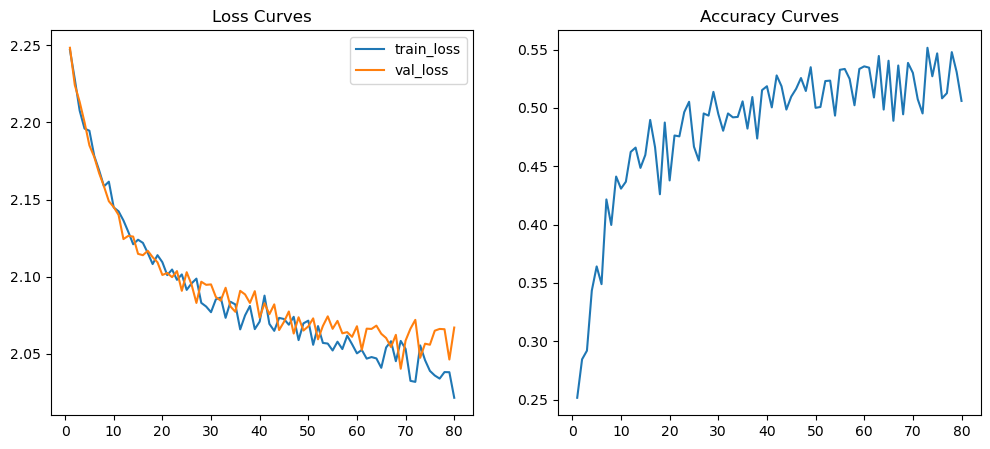

In [34]:
'''model.W1, model.b1 = best_params['W1'], best_params['b1']
model.W2, model.b2 = best_params['W2'], best_params['b2']'''
y_pred = model.predict(X_test)
print(classification_report(np.argmax(y_test, axis=1),y_pred))
print(confusion_matrix(np.argmax(y_test, axis=1),y_pred))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1,len(loss_list)+1), y=loss_list, label='train_loss')
sns.lineplot(x=range(1,len(val_loss_list)+1), y=val_loss_list,label='val_loss')
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
sns.lineplot(x=range(1,len(accuracy_list)+1), y=accuracy_list)
plt.title('Accuracy Curves')

In [36]:
np.savez('best_model.npz', **best_params)

In [52]:
#网格搜索
param_grid = {
    'lr': [0.5, 0.05],
    'hidden_size': [32, 64, 128],
    'weight_decay': [0.0001, 0.001]
}

def grid_search(param_grid, X_train, y_train, X_val, y_val,
                input_size, num_classes, batch_size=256, epochs=50):
    results = []
    keys = list(param_grid.keys())
    for values in itertools.product(*param_grid.values()):
        params = dict(zip(keys, values))
        print(f"\nTrying {params}")
        start = time.time()
        # 初始化模型
        model = MLP_3(input_size, params['hidden_size'], num_classes,
                            params.get('weight_decay', 0.0))
        # 训练
        _, val_loss_list, _, best_params = trainer(
            model, X_train, y_train, X_val, y_val,
            lr=params['lr'], batch_size=batch_size, epochs=epochs
        )
        elapsed = time.time() - start
        results.append({**params, 'best_val_loss': min(val_loss_list), 'time_sec': elapsed})
        print(f"Best val loss: {min(val_loss_list):.6f} (took {elapsed:.1f}s)")

    return pd.DataFrame(results)

In [53]:
results_ = grid_search(param_grid, X_train, y_train, X_val, y_val,
                X.shape[1], y.shape[1], batch_size=512, epochs=10)


Trying {'lr': 0.5, 'hidden_size': 32, 'weight_decay': 0.0001}


Epoch 1/10: 100%|███████████████████████████████████████████████████████| 43/43 [00:19<00:00,  2.17batch/s, loss=2.3053]


轮次1,loss2.305323,val loss2.305324,总计用时20.5179,速度20.5179s/epoch


Epoch 2/10: 100%|███████████████████████████████████████████████████████| 43/43 [00:21<00:00,  1.99batch/s, loss=2.3053]


轮次2,loss2.305273,val loss2.305279,总计用时43.0681,速度21.5341s/epoch


...

轮次8,loss2.266442,val loss2.265518,总计用时274.8856,速度34.3607s/epoch


Epoch 9/10: 100%|███████████████████████████████████████████████████████| 43/43 [00:33<00:00,  1.27batch/s, loss=2.2707]


轮次9,loss2.270702,val loss2.267750,总计用时309.4389,速度34.3821s/epoch


Epoch 10/10: 100%|██████████████████████████████████████████████████████| 43/43 [00:33<00:00,  1.27batch/s, loss=2.2502]

轮次10,loss2.250218,val loss2.259909,总计用时344.0298,速度34.4030s/epoch
Best val loss: 2.259909 (took 344.1s)


In [54]:
results_

,lr,hidden_size,weight_decay,best_val_loss,time_sec
0,0.50,32,0.0001,2.251820,226.344962
1,0.50,32,0.0010,2.316557,228.032142
2,0.50,64,0.0001,2.267897,271.089974
3,0.50,64,0.0010,2.395792,272.304080
4,0.50,128,0.0001,2.437733,362.113855
5,0.50,128,0.0010,4.053932,357.985893
6,0.05,32,0.0001,2.193370,229.660261
7,0.05,32,0.0010,2.210640,228.858705
8,0.05,64,0.0001,2.198701,269.458690
9,0.05,64,0.0010,2.223717,284.810025


In [55]:
results_.to_csv('grid_search.csv')